In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("D:\\Downloads\\mobile_app_interactions_csv.csv")
df


,user_id,session_id,device_os,event_type,app_version,session_duration_sec,is_subscribed,user_age,push_enabled,Unnamed: 9
0,13457,S-852694,Android,double_tap,2.6.8,3311,TRUE,51,FALSE,NaN
1,95977,S-766538,Android,pinch,3.3.6,3283,FALSE,40,FALSE,NaN
2,52758,S-228244,iOS,zoom,5.4.5,2870,TRUE,73,TRUE,NaN
3,53777,S-633216,iOS,long_press,4.7.1,332,TRUE,47,FALSE,NaN
4,6302,S-508537,Android,view,2.0.8,1694,TRUE,32,FALSE,NaN
...,...,...,...,...,...,...,...,...,...,...
99995,44090,S-426764,Android,like,1.2.1,2422,FALSE,68,TRUE,NaN
99996,25958,S-520236,Android,share,3.4.6,2752,FALSE,21,TRUE,NaN
99997,82660,S-856365,iOS,click,5.8.6,2478,FALSE,51,TRUE,NaN
99998,67802,S-593427,Android,scroll,1.4.1,1449,FALSE,78,FALSE,NaN


In [3]:
#DATA PREPARATION 

In [4]:
df.head()

,user_id,session_id,device_os,event_type,app_version,session_duration_sec,is_subscribed,user_age,push_enabled,Unnamed: 9
0,13457,S-852694,Android,double_tap,2.6.8,3311,TRUE,51,FALSE,NaN
1,95977,S-766538,Android,pinch,3.3.6,3283,FALSE,40,FALSE,NaN
2,52758,S-228244,iOS,zoom,5.4.5,2870,TRUE,73,TRUE,NaN
3,53777,S-633216,iOS,long_press,4.7.1,332,TRUE,47,FALSE,NaN
4,6302,S-508537,Android,view,2.0.8,1694,TRUE,32,FALSE,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               99659 non-null  str    
 1   session_id            99680 non-null  str    
 2   device_os             99686 non-null  str    
 3   event_type            99650 non-null  str    
 4   app_version           99670 non-null  str    
 5   session_duration_sec  99680 non-null  str    
 6   is_subscribed         99660 non-null  str    
 7   user_age              99649 non-null  str    
 8   push_enabled          99662 non-null  str    
 9   Unnamed: 9            0 non-null      float64
dtypes: float64(1), str(9)
memory usage: 7.6 MB


In [6]:
df.describe(include="all")

,user_id,session_id,device_os,event_type,app_version,session_duration_sec,is_subscribed,user_age,push_enabled,Unnamed: 9
count,99659,99680,99686,99650,99670,99680,99660,99649,99662,0.0
unique,63120,94372,577,646,1118,4167,562,662,541,NaN
top,44686,S-604531,Android,click,2.3.5,367,FALSE,38,FALSE,NaN
freq,8,4,56622,10067,236,44,49579,1560,49594,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['user_id'].astype(str).apply(lambda x: type(x)).value_counts()



user_id
<class 'str'>      99659
<class 'float'>      341
Name: count, dtype: int64

In [8]:
df['user_id'].isnull().sum()

np.int64(341)

In [9]:
df.isnull().sum()

user_id                    341
session_id                 320
device_os                  314
event_type                 350
app_version                330
session_duration_sec       320
is_subscribed              340
user_age                   351
push_enabled               338
Unnamed: 9              100000
dtype: int64

In [10]:
df = df.drop(columns=['Unnamed: 9'])

In [11]:
df.head()

,user_id,session_id,device_os,event_type,app_version,session_duration_sec,is_subscribed,user_age,push_enabled
0,13457,S-852694,Android,double_tap,2.6.8,3311,TRUE,51,FALSE
1,95977,S-766538,Android,pinch,3.3.6,3283,FALSE,40,FALSE
2,52758,S-228244,iOS,zoom,5.4.5,2870,TRUE,73,TRUE
3,53777,S-633216,iOS,long_press,4.7.1,332,TRUE,47,FALSE
4,6302,S-508537,Android,view,2.0.8,1694,TRUE,32,FALSE


In [12]:
df.shape

(100000, 9)

In [13]:
df_after=df.dropna()
df_after

,user_id,session_id,device_os,event_type,app_version,session_duration_sec,is_subscribed,user_age,push_enabled
0,13457,S-852694,Android,double_tap,2.6.8,3311,TRUE,51,FALSE
1,95977,S-766538,Android,pinch,3.3.6,3283,FALSE,40,FALSE
2,52758,S-228244,iOS,zoom,5.4.5,2870,TRUE,73,TRUE
3,53777,S-633216,iOS,long_press,4.7.1,332,TRUE,47,FALSE
4,6302,S-508537,Android,view,2.0.8,1694,TRUE,32,FALSE
...,...,...,...,...,...,...,...,...,...
99995,44090,S-426764,Android,like,1.2.1,2422,FALSE,68,TRUE
99996,25958,S-520236,Android,share,3.4.6,2752,FALSE,21,TRUE
99997,82660,S-856365,iOS,click,5.8.6,2478,FALSE,51,TRUE
99998,67802,S-593427,Android,scroll,1.4.1,1449,FALSE,78,FALSE


In [14]:
df= df.dropna(subset=["user_id"])

In [15]:
df.isnull().sum()

user_id                   0
session_id              316
device_os               313
event_type              348
app_version             329
session_duration_sec    320
is_subscribed           339
user_age                351
push_enabled            337
dtype: int64

In [16]:
df= df.dropna(subset=["session_id", "session_duration_sec"])

In [17]:
df["device_os"]=df["device_os"].fillna("Unknown")
df["event_type"]=df["event_type"].fillna("Unknown")
df["app_version"]=df["app_version"].fillna("Unknown")

In [18]:
df.isnull().sum()

user_id                   0
session_id                0
device_os                 0
event_type                0
app_version               0
session_duration_sec      0
is_subscribed           335
user_age                347
push_enabled            336
dtype: int64

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 99024 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               99024 non-null  str  
 1   session_id            99024 non-null  str  
 2   device_os             99024 non-null  str  
 3   event_type            99024 non-null  str  
 4   app_version           99024 non-null  str  
 5   session_duration_sec  99024 non-null  str  
 6   is_subscribed         98689 non-null  str  
 7   user_age              98677 non-null  str  
 8   push_enabled          98688 non-null  str  
dtypes: str(9)
memory usage: 7.6 MB


In [20]:
df["user_age"]= pd.to_numeric(df["user_age"], errors="coerce")

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 99024 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               99024 non-null  str    
 1   session_id            99024 non-null  str    
 2   device_os             99024 non-null  str    
 3   event_type            99024 non-null  str    
 4   app_version           99024 non-null  str    
 5   session_duration_sec  99024 non-null  str    
 6   is_subscribed         98689 non-null  str    
 7   user_age              98060 non-null  float64
 8   push_enabled          98688 non-null  str    
dtypes: float64(1), str(8)
memory usage: 7.6 MB


In [22]:
df["user_Age"]= df["user_age"].fillna(df["user_age"].median())

In [23]:
df["is_subscribed"]=df["is_subscribed"].fillna(False)

In [24]:
df["push_enabled"]=df["push_enabled"].fillna(False)

In [25]:
df.isnull().sum()

user_id                   0
session_id                0
device_os                 0
event_type                0
app_version               0
session_duration_sec      0
is_subscribed             0
user_age                964
push_enabled              0
user_Age                  0
dtype: int64

In [26]:
df["user_Age"]= df["user_age"].fillna(df["user_age"].median())

In [27]:
df["user_Age"].isnull().sum()

np.int64(0)

In [28]:
df.isnull().sum()

user_id                   0
session_id                0
device_os                 0
event_type                0
app_version               0
session_duration_sec      0
is_subscribed             0
user_age                964
push_enabled              0
user_Age                  0
dtype: int64

In [30]:
df[['user_age','user_Age']].head()

,user_age,user_Age
0,51.0,51.0
1,40.0,40.0
2,73.0,73.0
3,47.0,47.0
4,32.0,32.0


In [33]:
df['user_age'] = df['user_Age']

In [34]:
df.drop(columns=['user_Age'],inplace=True)

In [35]:
df.isnull().sum()

user_id                 0
session_id              0
device_os               0
event_type              0
app_version             0
session_duration_sec    0
is_subscribed           0
user_age                0
push_enabled            0
dtype: int64

In [ ]:
#Exploratory Data Analysis


In [40]:
df["device_os"].value_counts()

device_os
Android    56018
iOS        42037
Unknown      311
iO6            4
Andromd        4
           ...  
NzrTYB         1
iOo            1
Endroid        1
cuPwvO         1
b96Ppa         1
Name: count, Length: 573, dtype: int64

In [41]:
df["device_os"]=df["device_os"].str.lower().str.strip()

In [42]:
df["device_os"]= df["device_os"].replace({
    "endroid": "android",
    "andromd": "android",
    "ioo" : "ios",
    "io6" : "ios"})

In [43]:
valid_os= ["android", "ios"]

In [44]:
df["device_os"]=df["device_os"].apply(lambda x: x if x in valid_os else"unknown")

In [45]:
df["device_os"].value_counts()

device_os
android    56027
ios        42044
unknown      953
Name: count, dtype: int64

In [46]:
df["event_type"].value_counts()

event_type
click         9976
share         9966
swipe         9848
scroll        9812
view          9803
              ... 
Hxu8se           1
MU8svw           1
koom             1
lonX_press       1
shar4            1
Name: count, Length: 635, dtype: int64

In [47]:
df["event_type"]=df["event_type"].str.lower().str.strip()

In [48]:
df["event_type"]=df["event_type"].replace({
    "koom": "zoom",
    "lonx_press": "long_press",
    "shar4": "share",
    "hxu8se": "tap",
    "mu8svw": "tap"})

In [49]:
valid_et= ["click","share","swipe","scroll","view","zoom","long_press","tap"]

In [50]:
df["event_type"]= df["event_type"].apply(lambda x: x if x in valid_et else "unknown")

In [51]:
df["event_type"].value_counts()

event_type
unknown       30052
click          9977
share          9968
swipe          9849
scroll         9813
view           9804
long_press     9780
zoom           9779
tap               2
Name: count, dtype: int64

In [52]:
df["event_type"].value_counts(normalize=True)*100

event_type
unknown       30.348198
click         10.075335
share         10.066247
swipe          9.946074
scroll         9.909719
view           9.900630
long_press     9.876394
zoom           9.875384
tap            0.002020
Name: proportion, dtype: float64

In [53]:
df["event_type"].value_counts().head(20)

event_type
unknown       30052
click          9977
share          9968
swipe          9849
scroll         9813
view           9804
long_press     9780
zoom           9779
tap               2
Name: count, dtype: int64

In [54]:
df["event_type"].nunique()

9

In [55]:
df_clean= df[df["event_type"]!= "unknown"]

In [56]:
df_clean.shape

(68972, 9)

In [57]:
df_clean["event_type"].value_counts()

event_type
click         9977
share         9968
swipe         9849
scroll        9813
view          9804
long_press    9780
zoom          9779
tap              2
Name: count, dtype: int64

In [58]:
df_clean["device_os"].value_counts()

device_os
android    39023
ios        29305
unknown      644
Name: count, dtype: int64

In [60]:
df_clean[["device_os","event_type"]].value_counts()

device_os  event_type
android    click         5649
           share         5648
           long_press    5599
           zoom          5557
           scroll        5539
           view          5524
           swipe         5507
ios        swipe         4240
           share         4238
           click         4231
           view          4206
           scroll        4163
           zoom          4122
           long_press    4103
unknown    scroll         111
           swipe          102
           zoom           100
           click           97
           share           82
           long_press      78
           view            74
ios        tap              2
Name: count, dtype: int64

In [61]:
df["session_duration_sec"].value_counts()

session_duration_sec
367       44
3426      44
355       43
3338      43
2173      43
          ..
3Y18       1
tMjyL7     1
ZjjBRr     1
1Q75       1
TmoWtU     1
Name: count, Length: 4160, dtype: int64

In [62]:
df_clean["session_duration_sec"]= pd.to_numeric(df_clean["session_duration_sec"],errors="coerce")

In [63]:
df_clean["session_duration_sec"]=df_clean["session_duration_sec"].fillna(df_clean["session_duration_sec"].median())

In [64]:
df_clean["session_duration_sec"].isnull().sum()

np.int64(0)

In [65]:
df_clean["session_duration_sec"].mean()

np.float64(2.8997274256219914e+34)

In [66]:
df_clean["session_duration_sec"].describe()

count    6.897200e+04
mean     2.899727e+34
std      7.615415e+36
min      4.000000e+00
25%      9.140000e+02
50%      1.806000e+03
75%      2.705000e+03
max      2.000000e+39
Name: session_duration_sec, dtype: float64

In [67]:
df_clean= df_clean[df_clean["session_duration_sec"]<10000]

In [68]:
df_clean["session_duration_sec"].describe()

count    68971.000000
mean      1808.756405
std       1036.590328
min          4.000000
25%        914.000000
50%       1806.000000
75%       2705.000000
max       7319.000000
Name: session_duration_sec, dtype: float64

In [69]:
df_clean["session_duration_sec"].mean()

np.float64(1808.7564048658132)

In [70]:
df_clean.groupby("is_subscribed")["session_duration_sec"].mean()

is_subscribed
False     1841.921162
03Bi0C     848.000000
07fB6Y    2800.000000
0EMmi0    2488.000000
0Ppb0x    1008.000000
             ...     
zAOLOo    1207.000000
zMY6hi    1560.000000
zOVN1o    3152.000000
zaefcr    2568.000000
zhxPAD    1761.000000
Name: session_duration_sec, Length: 398, dtype: float64

In [71]:
df_clean['is_subscribed'] = df_clean['is_subscribed'].astype(str).str.lower().str.strip()

In [72]:
df_clean['is_subscribed'] = df_clean['is_subscribed'].replace({
    'true': True,
    'false': False
})

In [73]:
df_clean['is_subscribed'] = df_clean['is_subscribed'].apply(
    lambda x: x if x in [True, False] else 'unknown'
)

In [74]:
df_clean['is_subscribed'] = df_clean['is_subscribed'].apply(
    lambda x: True if x == True else False
)

In [75]:
df_clean['is_subscribed'].value_counts()

is_subscribed
False    34834
True     34137
Name: count, dtype: int64

In [76]:
df_clean.groupby('is_subscribed')['session_duration_sec'].mean()

is_subscribed
False    1811.486737
True     1805.970325
Name: session_duration_sec, dtype: float64

*There is no significant difference in session duration between subscribed and non-subscribed users, suggesting that subscription status does not strongly influence user engagement in terms of time spent.

In [77]:
df_clean.groupby('push_enabled')['session_duration_sec'].mean()

push_enabled
False     1758.61991
0SbKow    3170.00000
0rue      2206.00000
16myfm    3376.00000
1VMOVk     774.00000
             ...    
zEiJgv    1104.00000
zalse      847.00000
zpelw1    2373.00000
zpqWi9    3015.00000
zrue       943.00000
Name: session_duration_sec, Length: 380, dtype: float64

In [78]:
df_clean['push_enabled'] = df_clean['push_enabled'].astype(str).str.lower().str.strip()

In [79]:
df_clean['push_enabled'] = df_clean['push_enabled'].replace({
    'true': True,
    'false': False
})

In [80]:
df_clean['push_enabled'] = df_clean['push_enabled'].apply(
    lambda x: x if x in [True, False] else 'unknown'
)

In [81]:
df_clean['push_enabled'] = df_clean['push_enabled'].apply(
    lambda x: True if x == True else False
)

In [82]:
df_clean['push_enabled'].value_counts()

push_enabled
False    34801
True     34170
Name: count, dtype: int64

In [83]:
df_clean.groupby('push_enabled')['session_duration_sec'].mean()

push_enabled
False    1809.079509
True     1808.427334
Name: session_duration_sec, dtype: float64

*Analysis shows that neither subscription status nor push notification settings significantly impact session duration. Users spend nearly the same amount of time on the platform regardless of these factors, suggesting that engagement may be driven by other variables such as content quality or user intent.

In [84]:
df_clean.groupby('event_type')['session_duration_sec'].mean()

event_type
click         1803.157362
long_press    1812.193354
scroll        1824.685112
share         1800.200261
swipe         1805.271601
tap           1076.500000
view          1797.880559
zoom          1818.331220
Name: session_duration_sec, dtype: float64

*User interactions involving deeper engagement, such as scrolling and zooming, are associated with longer session durations, whereas lighter interactions like viewing and sharing result in comparatively shorter sessions.

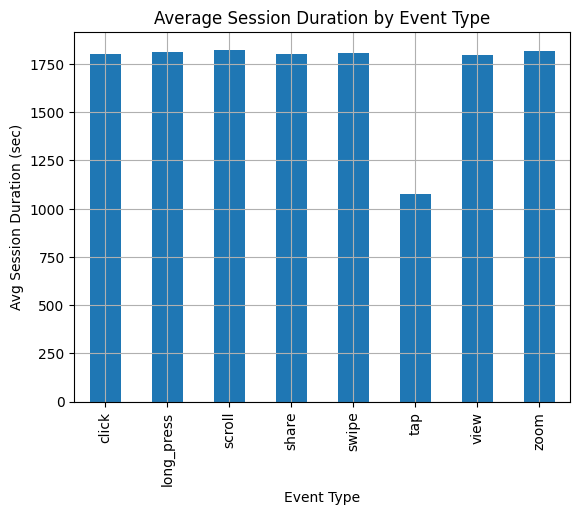

In [85]:
df_clean.groupby('event_type')['session_duration_sec'].mean().plot(kind='bar')
plt.title("Average Session Duration by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Avg Session Duration (sec)")
plt.grid()
plt.show()

Session duration remains relatively consistent across most interaction types, indicating that no single action significantly drives user engagement. However, tap shows significantly lower duration, likely due to limited or unreliable data.

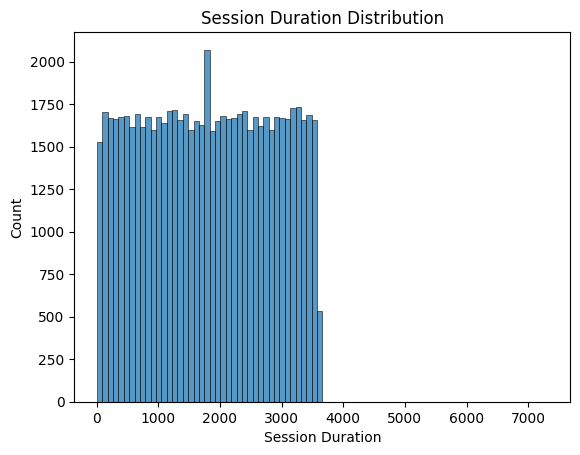

In [86]:
sns.histplot(df_clean['session_duration_sec'])
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration")
plt.show()

Session duration appears to be uniformly distributed across a wide range of values, with no strong concentration around a specific duration. This suggests that user engagement varies widely and does not follow a typical skewed pattern.

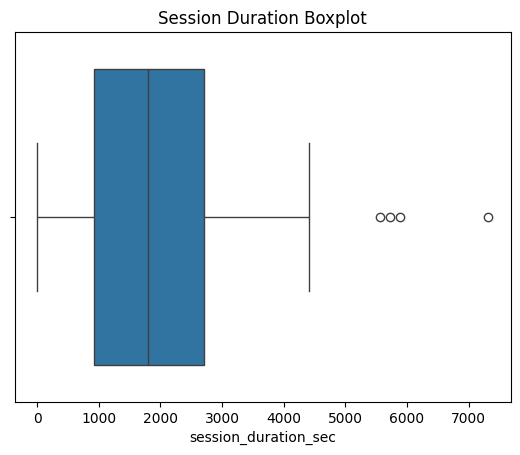

In [87]:
sns.boxplot(x=df_clean['session_duration_sec'])
plt.title("Session Duration Boxplot")
plt.show()

Session duration shows high variability among users, with a median of approximately 30 minutes. While most sessions fall within a moderate range, the presence of high-value outliers indicates a segment of highly engaged users who spend significantly more time on the platform.

In [88]:
from scipy.stats import ttest_ind

subscribed = df_clean[df_clean['is_subscribed'] == True]['session_duration_sec']
not_subscribed = df_clean[df_clean['is_subscribed'] == False]['session_duration_sec']

ttest_ind(subscribed, not_subscribed)

TtestResult(statistic=np.float64(-0.6987615369910434), pvalue=np.float64(0.48470342567243135), df=np.float64(68969.0))

**Hypothesis Test: Subscription vs Session Duration

Objective:
To determine whether subscription status has a significant impact on user engagement (measured by session duration).

Hypotheses:

H₀ (Null Hypothesis): There is no difference in mean session duration between subscribed and non-subscribed users.
H₁ (Alternative Hypothesis): There is a difference in mean session duration between the two groups.

Test Used:
Independent two-sample t-test

Results:

t-statistic = -0.699
p-value = 0.485

Decision Rule:
At a significance level of α = 0.05, reject H₀ if p-value < 0.05.

Conclusion:
Since the p-value (0.485) is significantly greater than 0.05, we fail to reject the null hypothesis.
Insight:
There is no statistically significant difference in session duration between subscribed and non-subscribed users. This suggests that subscription status does not meaningfully influence how long users engage with the app.

Business Implication:
Subscription alone may not be a strong driver of user engagement. Other factors—such as content quality, user experience, or feature design—may play a more critical role in influencing session duration.

In [89]:
from scipy.stats import ttest_ind

push_true = df_clean[df_clean['push_enabled'] == True]['session_duration_sec']
push_false = df_clean[df_clean['push_enabled'] == False]['session_duration_sec']

ttest_ind(push_true, push_false)

TtestResult(statistic=np.float64(-0.08261124192158777), pvalue=np.float64(0.9341609018099056), df=np.float64(68969.0))

**Hypothesis Test: Push Notifications vs Session Duration

Objective:
To evaluate whether enabling push notifications has a significant impact on user engagement (measured by session duration).

Hypotheses:

H₀ (Null Hypothesis): There is no difference in mean session duration between users with push notifications enabled and disabled.
H₁ (Alternative Hypothesis): There is a difference in mean session duration between the two groups.

Test Used:
Independent two-sample t-test

Results:

t-statistic = -0.083
p-value = 0.934

Decision Rule:
At a significance level of α = 0.05, reject H₀ if p-value < 0.05.

Conclusion:
Since the p-value (0.934) is much greater than 0.05, we fail to reject the null hypothesis.

Insight:
There is no statistically significant difference in session duration between users with push notifications enabled and those without. This indicates that push notifications do not have a measurable impact on how long users engage with the app.

Business Implication:
Push notifications alone may not be effective in increasing user engagement. Their impact might depend on factors such as content relevance, timing, personalization, or user preferences rather than simply being enabled.

User engagement is not significantly influenced by subscription status or push notification settings, suggesting that intrinsic factors such as content quality or user intent may play a more dominant role.

## Final Conclusion

### 🔹 Objective

* Analyze mobile user interaction data to understand engagement patterns
* Evaluate the impact of:

  * Subscription status
  * Push notification settings
  * User interaction types

---

### 🔹 Data Preparation

* Handled missing values and inconsistent formats
* Standardized categorical variables (device_os, event_type, etc.)
* Converted numerical columns to correct data types
* Removed invalid and extreme values while retaining meaningful outliers

---

### 🔹 Key Observations from EDA

* Most frequent user actions:

  * Click, Share, Scroll dominate interactions
* Device distribution:

  * Majority users on Android, followed by iOS
* Average session duration:

  * ~1800 seconds (~30 minutes)
* High variability in session duration:

  * Indicates diverse user engagement behavior
* Presence of high-duration outliers:

  * Represents highly engaged or “power” users

---

### 🔹 Behavioral Insights

* Session duration is relatively consistent across most interaction types
* No single event type significantly drives higher engagement
* Deeper interactions (scroll, zoom) show slightly higher engagement, but differences are minimal

---

### 🔹 Hypothesis Testing Results

#### 1. Subscription vs Engagement

* p-value > 0.05
* ❌ No statistically significant difference
* ➤ Subscription does not meaningfully impact session duration

#### 2. Push Notifications vs Engagement

* p-value > 0.05
* ❌ No statistically significant difference
* ➤ Push notifications do not significantly affect engagement

---

### 🔹 Overall Findings

* User engagement remains consistent regardless of:

  * Subscription status
  * Push notification settings
* Engagement is not strongly influenced by surface-level features
* High variability suggests user behavior is influenced by deeper factors

---

### 🔹 Final Insight

* User engagement is likely driven by:

  * Content quality
  * User intent
  * Overall app experience
* Feature-based strategies alone (subscriptions, notifications) are insufficient to significantly impact engagement

---

### 🔹 Conclusion Statement

* The analysis highlights that improving core user experience and content value is more critical than relying on subscription models or notification strategies to drive engagement.
